# FoundationStereo 2448 × 2048 离线推理

从 `data/<timestamp>/left.png`、`right.png`、`masks/left_mask.png` 与 `calibration.json` 读取一组原始双目图像。掩码与原始左图对齐，使用相同的左图 rectification map 重映射后用于筛选点云。先运行模型加载单元一次；切换数据时只需要重跑数据、推理和导出单元。不会创建 Open3D 可视化窗口。

## 1. 环境与共用工具

In [1]:
%load_ext autoreload
%autoreload 2

from fs_high_resolution_utils import *
REPO_ROOT, FS_ROOT, DEVICE = bootstrap_notebook(globals())
print('Repository:', REPO_ROOT)
print('GPU:', torch.cuda.get_device_name(DEVICE))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Repository: /home/liu4000/Desktop/FS_realsense
GPU: NVIDIA RTX PRO 4000 Blackwell


## 2. 只加载一次：FoundationStereo 模型

切换时间戳数据时，不需要重新运行本单元。

In [2]:
model, CKPT_PATH = load_foundation_stereo_model(FS_ROOT, DEVICE)
print(f'Model loaded: {CKPT_PATH.name}')
print({k: f'{v:.1f} MiB' for k, v in gpu_memory_mib().items()})

Using cache found in /home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
using MLP layer as FFN


Model loaded: model_best_bp2.pth
{'allocated': '1431.9 MiB', 'reserved': '1436.0 MiB', 'peak_allocated': '1431.9 MiB', 'peak_reserved': '1436.0 MiB'}


## 3. 选择一组数据

In [3]:
# 只修改这个数据组目录名，即可切换测试数据。
CAPTURE_DIR = configure_capture(globals(), REPO_ROOT, 'example_data')
print('Capture:', CAPTURE_DIR)
print('Point cloud directory:', POINT_CLOUD_DIR)
print('Mask:', LEFT_MASK_PATH)

Capture: /home/liu4000/Desktop/FS_realsense/data/example_data
Point cloud directory: /home/liu4000/Desktop/FS_realsense/data/example_data
Mask: /home/liu4000/Desktop/FS_realsense/data/example_data/masks/left_mask.png


## 4. 加载原始图片并进行 stereo rectification

使用保存的 OpenCV-matrix JSON。`rectified_K`、`baseline_m` 和校正后的 `left_mask` 均在同一坐标系，用于后续深度和点云投影。

Rectified: 2448x2048, fx=1723.58, baseline=0.055079 m
Mask: 1,326,078 / 5,013,504 rectified pixels selected


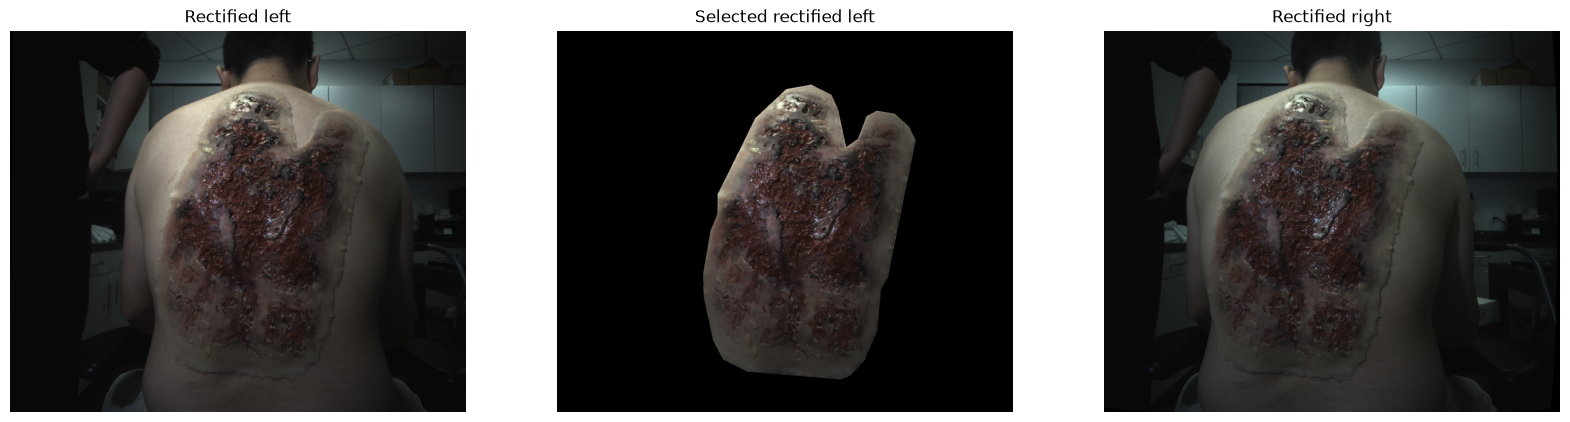

In [4]:
rectified_left, rectified_right, rectified_K, baseline_m, rectified_left_mask = load_rectify_and_select_mask(
    globals(), LEFT_PATH, RIGHT_PATH, LEFT_MASK_PATH, CALIBRATION_PATH, EXPECTED_WIDTH, EXPECTED_HEIGHT
)
print(f'Rectified: {rectified_left.shape[1]}x{rectified_left.shape[0]}, fx={rectified_K[0,0]:.2f}, baseline={baseline_m:.6f} m')
print(f'Mask: {rectified_left_mask.sum():,} / {rectified_left_mask.size:,} rectified pixels selected')
show_rectified_selection(rectified_left, rectified_left_mask, rectified_right)

## 5. 高分辨率 inference：时间与 GPU memory

2448×2048 会先由 `InputPadder` 左右各补 8 px，模型实际输入为 2464×2048。`HIERA=1` 先在一半分辨率推理，再以其视差初始化全分辨率精修。计时仅包含模型推理和 GPU 同步，不含图像读取、rectification 和点云处理。

In [5]:
VALID_ITERS, HIERA, WARMUP_RUNS = 32, 1, 1
inference = run_foundation_stereo_inference(
    model, rectified_left, rectified_right, DEVICE, VALID_ITERS, HIERA, WARMUP_RUNS
)
disparity = inference.disparity
print(f'Inference: {inference.seconds:.3f} s | hiera={HIERA} | valid_iters={VALID_ITERS}')
print('GPU before:', {k: f'{v:.1f} MiB' for k, v in inference.memory_before_mib.items()})
print('GPU after: ', {k: f'{v:.1f} MiB' for k, v in inference.memory_after_mib.items()})
finite_disparity = disparity[torch.isfinite(disparity)]
print(f'Disparity: {tuple(disparity.shape)}, min={finite_disparity.min().item():.3f}, max={finite_disparity.max().item():.3f}')

/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/foundation_stereo.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/submodule.py:390: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/geometry.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/foundation_stereo.py:245: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precisio

Inference: 8.375 s | hiera=1 | valid_iters=32
GPU before: {'allocated': '1463.9 MiB', 'reserved': '15786.0 MiB', 'peak_allocated': '1463.9 MiB', 'peak_reserved': '15786.0 MiB'}
GPU after:  {'allocated': '1483.2 MiB', 'reserved': '15786.0 MiB', 'peak_allocated': '12374.1 MiB', 'peak_reserved': '15786.0 MiB'}
Disparity: (2048, 2448), min=28.048, max=262.815


## 6. 去噪、Constrained Delaunay 网格与最终导出

视差到深度、`remove_invisible`、距离与 `left_mask.png` 过滤、XYZ 反投影和 3×3 邻域去噪均在 CUDA 上完成。之后在 CPU 的图像 `(u, v)` 平面执行 Constrained Delaunay：原始选区的外轮廓是硬约束，去噪留下的小洞允许由周围有效点跨越。最后仅保存带颜色的三角网格 PLY；不会生成点云 PLY 或打开 Open3D 窗口。

In [9]:
REMOVE_INVISIBLE, DENOISE_CLOUD = True, True
Z_FAR_M = 1.0
DENOISE_MAX_NEIGHBOR_DISTANCE_M, DENOISE_MIN_NEIGHBORS = 0.01, 3
DENOISE_EDGE_MIN_NEIGHBORS = 2
surface = postprocess_disparity_gpu(
    disparity, rectified_K, baseline_m, rectified_left_mask, DEVICE, Z_FAR_M,
    remove_invisible=REMOVE_INVISIBLE, denoise=DENOISE_CLOUD,
    max_neighbor_distance_m=DENOISE_MAX_NEIGHBOR_DISTANCE_M,
    min_neighbors=DENOISE_MIN_NEIGHBORS,
    edge_min_neighbors=DENOISE_EDGE_MIN_NEIGHBORS,
)
xyz_map, point_mask = surface.xyz_map, surface.keep_mask
# Build one mesh for inspection; this cell does not write a PLY file.
DOWNSAMPLE_PIXELS = 4
MESH_MAX_EDGE_M = 0.02
MESH_MAX_DEPTH_JUMP_M = 0.01

mesh_result = build_constrained_mesh(
    xyz_map, point_mask, rectified_left_mask, rectified_left,
    downsample_pixels=DOWNSAMPLE_PIXELS,
    max_edge_m=MESH_MAX_EDGE_M,
    max_depth_jump_m=MESH_MAX_DEPTH_JUMP_M,
)
print(
    f'downsample={DOWNSAMPLE_PIXELS}px | '
    f'area={mesh_result.area_m2:.6f} m² ({mesh_result.area_m2 * 1e4:.2f} cm²) | '
    f'vertices={len(mesh_result.vertices):,} | '
    f'triangles={len(mesh_result.triangles):,}'
)
mesh_path = POINT_CLOUD_DIR / f'mesh.ply'
save_triangle_mesh(mesh_result, mesh_path)
print('Saved:', mesh_path)


downsample=4px | area=0.088146 m² (881.46 cm²) | vertices=87,059 | triangles=169,633
Saved: /home/liu4000/Desktop/FS_realsense/data/example_data/mesh.ply
